## Practical Work (TD #2): Support Vector Machines on the Penguins Dataset

1. Apply Support Vector Machines (SVM) to classify penguin species based on body measurements.
2. Explore:
    - preprocessing
    - visualization
    - model training
    - evaluation
    - hyperparameter tuning.

### 🧠 Dataset
* We’ll use Seaborn’s penguins dataset, which contains data about three penguin species:
    - Adelie
    - Chinstrap
    - Gentoo
* Each sample includes physical characteristics like bill length, flipper length, and body mass.

In [ ]:
#upload the dataset
#your code here
# Load dataset
penguins = sns.load_dataset("penguins")
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## ⚙️ Step 1 — Load and Explore the Dataset

**Import libraries:**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


### Step 2 — Encode and Visualize the Data

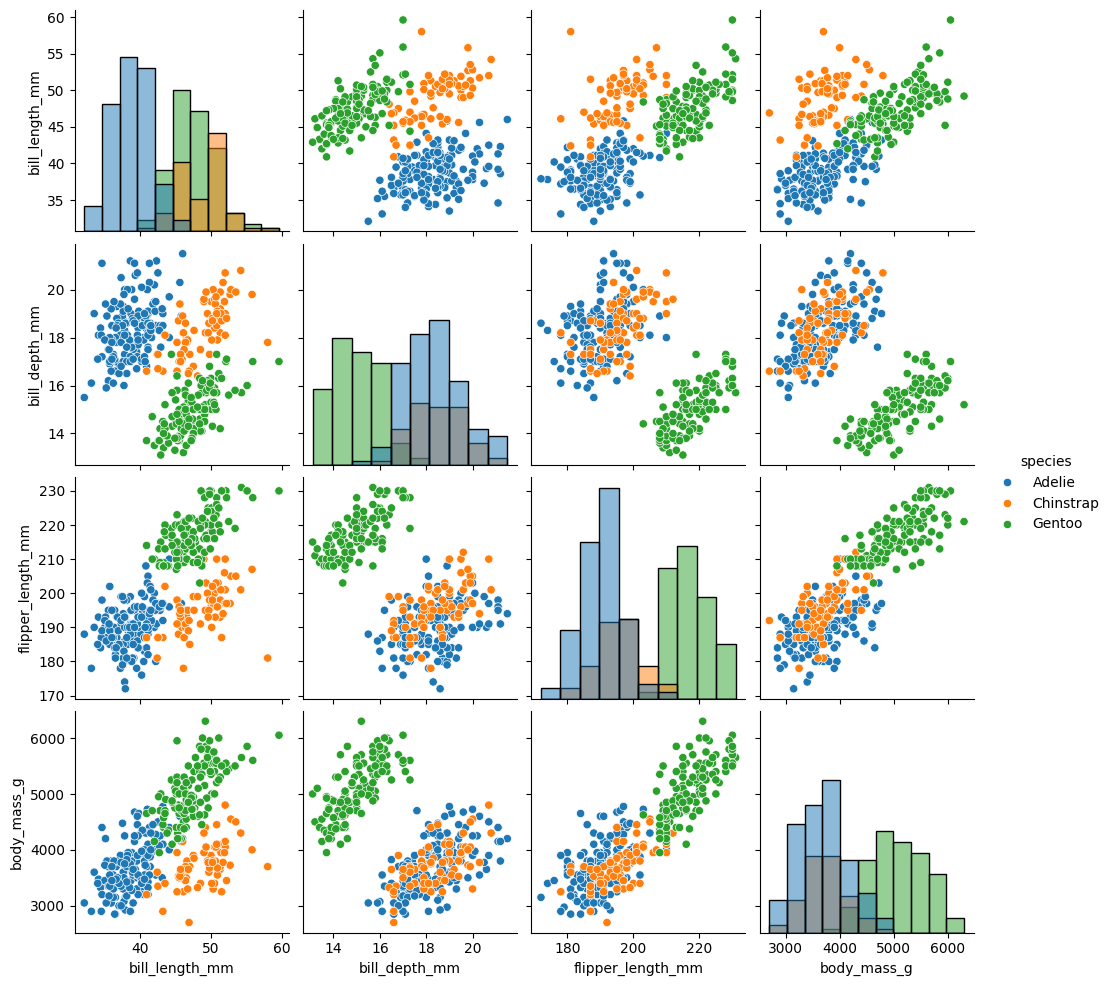

In [ ]:

penguins_clean = penguins.dropna().copy()
sns.pairplot(penguins, hue='species', diag_kind='hist')
plt.show()


In [ ]:
# Encode target
le = LabelEncoder()
penguins_clean['species_enc'] = le.fit_transform(penguins_clean['species'])

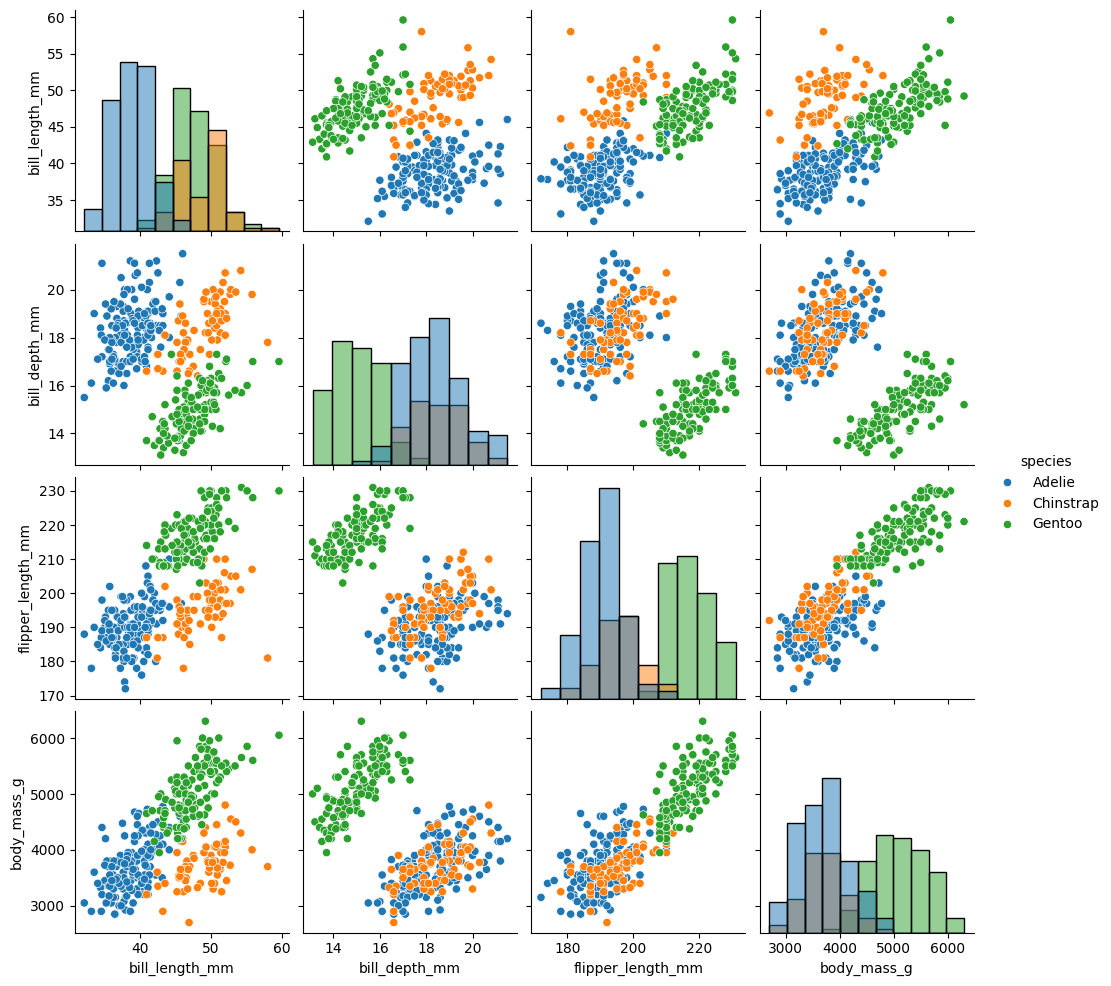

In [ ]:
sns.pairplot(
    penguins_clean,
    hue='species',
    diag_kind='hist',
    vars=['bill_length_mm', 'bill_depth_mm',
          'flipper_length_mm', 'body_mass_g']
)
plt.show()

Question:

**Q1**: Do you observe overlap between species?

Yes, there is noticeable overlap, especially between Adelie and Chinstrap in bill-related features. Gentoo is more clearly separated due to larger body mass and flipper length.

**Q2**:Which features seem most discriminative?

Flipper length

Body mass

These features clearly separate Gentoo penguins from the other species.

### 🧩 Step 3 — Split and Standardize

In [ ]:
X = penguins_clean[['bill_length_mm', 'bill_depth_mm',
                     'flipper_length_mm', 'body_mass_g']]
y = penguins_clean['species_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 🔹 Step 4 — Train a Linear SVM

In [ ]:
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_scaled, y_train)


SVC(C=1, kernel='linear')

In [ ]:
y_pred = svm_linear.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [ ]:
confusion_matrix(y_test, y_pred)


array([[29,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 24]])

In [ ]:
pd.Series(
    svm_linear.coef_[0],
    index=X.columns
).sort_values(ascending=False)


,0
body_mass_g,0.763818
bill_depth_mm,0.738451
flipper_length_mm,0.009157
bill_length_mm,-2.362334


Linear SVM performs well but struggles slightly with overlapping classes.

RBF kernel improves separation by modeling non-linear boundaries.

Scaling is essential for SVM.

Gentoo penguins are easiest to classify due to size-related features.